<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Assignment_12_Neural_Network_and_Deep_Learning_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 12: Neural Network and Deep Learning Basics**

Student name: Khadija bassiouni

**Dataset Choice:** For this assignment, I chose to work with Fashion MNIST dataset.

In [1]:
# Setting up the environment and importing important libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


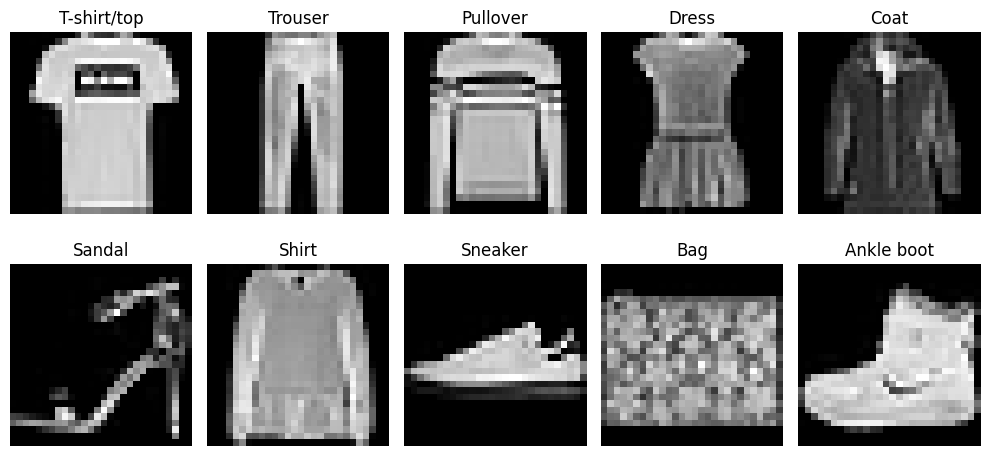

In [2]:
# Data Loading and Visualization

# Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class mapping
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plotting one sample image from each class
plt.figure(figsize=(10, 5))
for i in range(10):
    # Finding the index of the first image of class i
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
#Image Preprocessing:
# Scaling pixel values to range [0, 1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Setting up Data Augmentation layer using Keras Sequential pipeline
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
], name="data_augmentation")

In [5]:
# Model Architecture and Compilation

# Constructing a Feedforward Neural Network (Multi-Layer Perceptron)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Model Training
history = model.fit(
    X_train_norm, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8144 - loss: 0.5331 - val_accuracy: 0.8512 - val_loss: 0.4213
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8598 - loss: 0.3910 - val_accuracy: 0.8568 - val_loss: 0.3938
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8734 - loss: 0.3468 - val_accuracy: 0.8744 - val_loss: 0.3555
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8816 - loss: 0.3252 - val_accuracy: 0.8720 - val_loss: 0.3542
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8879 - loss: 0.3070 - val_accuracy: 0.8725 - val_loss: 0.3529
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8925 - loss: 0.2909 - val_accuracy: 0.8829 - val_loss: 0.3299
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8971 - loss: 0.2769 - val_accuracy: 0.8819 - val_loss: 0.3398
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9015 - loss: 0.2643 - val_accuracy: 0.

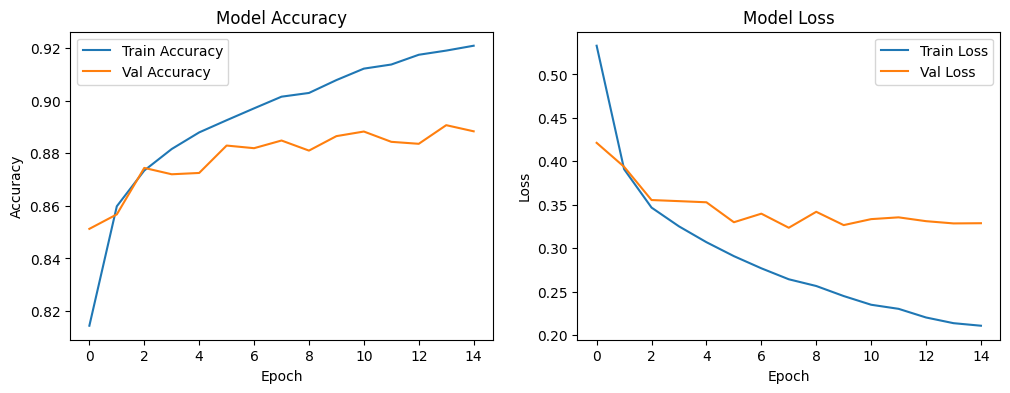

In [7]:
# Visualizing Training Curves
# Training & Validation Loss/Accuracy Plot

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

# Loss plot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.80      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.72      0.78      1000
       Dress       0.90      0.89      0.89      1000
        Coat       0.78      0.83      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.67      0.76      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



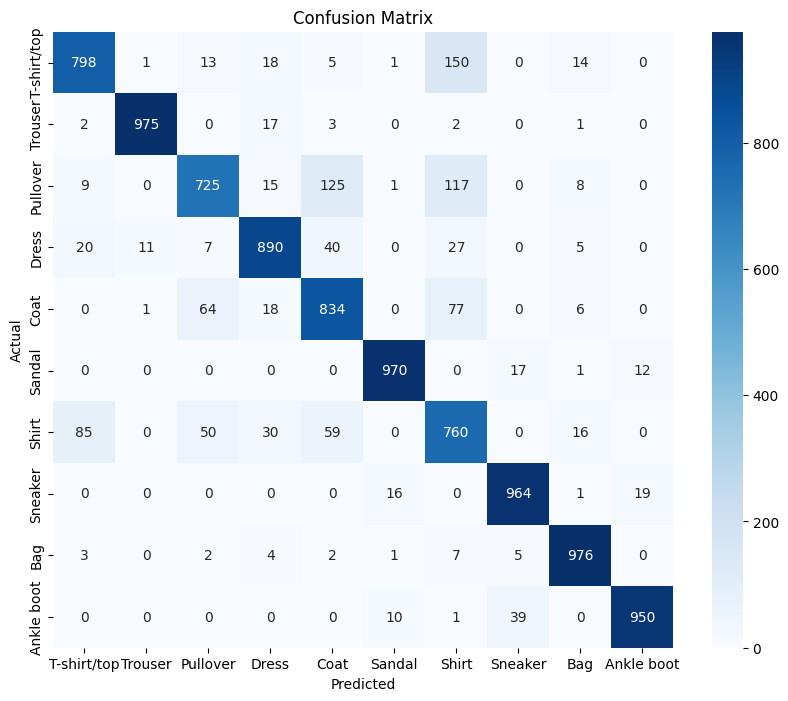

In [8]:
# Evaluation, Confusion Matrix & Classification Report

# Generating predictions on test set
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print Precision, Recall, F1-Score
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Report:**

Fashion MNIST requires capturing complex edge patterns and textures rather than basic strokes, that was why I chose it.
*Preprocessing:* Scaling pixel intensity from [0, 255] down to [0, 1] to improve numerical stability during backpropagation.

Hypothetical Scenario for a Practical Deployment: Automated inventory tagging for a fashion e-commerce warehouse platform.

Quick summary: feedforward architectures establishes a functional baseline for non-linear image classification.